A.4  Training the Models

Supervised Model – Random Forest Classifier Training (Breast Cancer)

In [ ]:
import gdown

# Downloading your three csv files
gdown.download(id='1A1apvtR7R2s6WBPACDwKXTyBRN4M1ex-', output='Grid search.csv', quiet=False)
gdown.download(id='1NNOdn0h4cEVTWzF1Mj9VFw3CCP31ebcS', output='Random search.csv', quiet=False)
gdown.download(id='1zlhrPqlYY0w_Eb7OMKw80Mkaf7iHSCl_', output='unsupervised.csv', quiet=False)

print("All files downloaded successfully!")

# loading them into pandas
import pandas as pd

df1 = pd.read_csv('Grid search.csv')
df2 = pd.read_csv('Random search.csv')
df3 = pd.read_csv('unsupervised.csv')

print("Files are loaded into DataFrames df1, df2, and df3.")

Downloading...
From: https://drive.google.com/uc?id=1A1apvtR7R2s6WBPACDwKXTyBRN4M1ex-
To: /content/Grid search.csv
100%|██████████| 125k/125k [00:00<00:00, 4.32MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NNOdn0h4cEVTWzF1Mj9VFw3CCP31ebcS
To: /content/Random search.csv
100%|██████████| 461k/461k [00:00<00:00, 7.18MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zlhrPqlYY0w_Eb7OMKw80Mkaf7iHSCl_
To: /content/unsupervised.csv
100%|██████████| 3.98k/3.98k [00:00<00:00, 11.0MB/s]

All files downloaded successfully!
Files are loaded into DataFrames df1, df2, and df3.


Supervised Model 1 : Random Forest Classifier Training

In [ ]:
# Importing libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score




In [ ]:
# Loading and cleaning data
df = pd.read_csv("Grid search.csv")
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")



In [ ]:
# Encoding target  (M=1 Malignant, B=0 Benign)
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])



In [ ]:

# Separating features and target
X = df.drop("diagnosis", axis=1)  # 30 features
y = df["diagnosis"]               # target column



In [ ]:
# Stratifing 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# Result: 455 training samples, 114 test samples



In [ ]:
# Training the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("RandomForestClassifier trained successfully.")
print(f"Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")
print(f"Classes: {[f'{i}={n}' for i, n in enumerate(le.classes_)]}")

RandomForestClassifier trained successfully.
Training set: 455 samples | Test set: 114 samples
Classes: ['0=B', '1=M']


Supervised Model 2 : Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train_sc, y_train)

LogisticRegression(max_iter=10000, random_state=42)

Unsupervised Model 1 : K-Means Clustering Training (Mall Customers)

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Step 2: Load data and select features
df = pd.read_csv("unsupervised.csv")
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

# Step 3: Scale features (very important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Elbow Method to find best K
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
# Plot the elbow curve (see Figure 4 below)

# Step 5: Train final model with K=5 (elbow point)
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = km5.fit_predict(X_scaled)

print(f"K-Means converged after {km5.n_iter_} iterations.")
print(f"Inertia (WCSS) = {km5.inertia_:.2f}  |  Silhouette Score = {silhouette_score(X_scaled, labels):.4f}")

K-Means converged after 4 iterations.
Inertia (WCSS) = 65.57  |  Silhouette Score = 0.5547


Unsupervised Model 2 : Hierarchical Clustering Training

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(X_scaled, method="ward")
hc_labels = fcluster(Z, t=5, criterion="maxclust") - 1
print(f"Linkage matrix computed | {len(np.unique(hc_labels))} clusters extracted")

Linkage matrix computed | 5 clusters extracted


A.5  Diagnostic Visualisations

Figure 1 – Confusion Matrix (Random Forest, Breast Cancer)

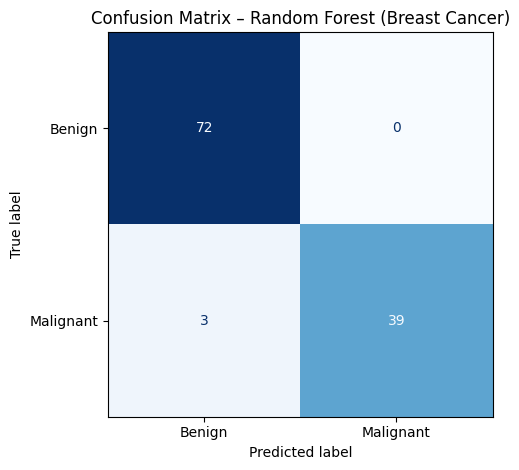

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix – Random Forest (Breast Cancer)")
plt.tight_layout()
plt.show()

Figure 2 – ROC Curve (Random Forest, Breast Cancer)

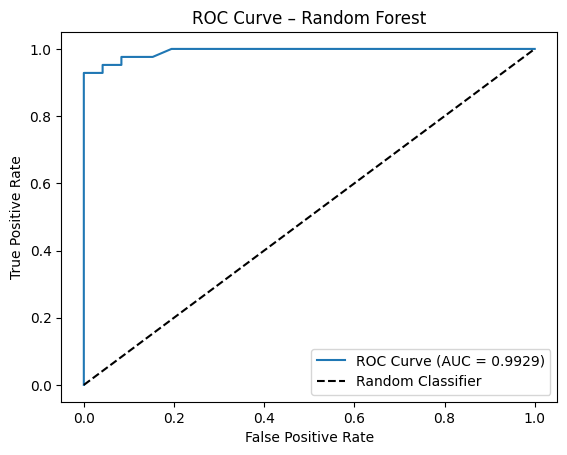

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:, 1]  # probability of Malignant
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],"k--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.show()

Confusion Matrix: Logistic Regression

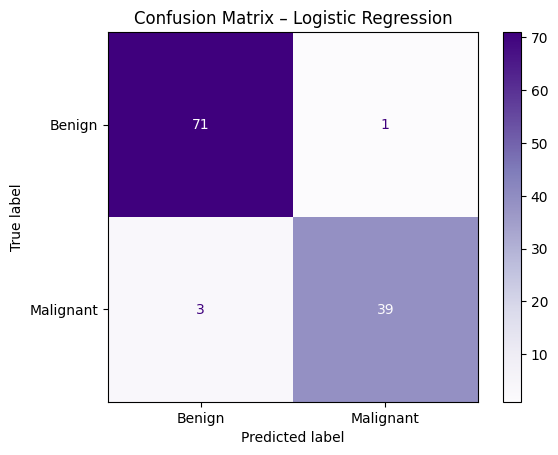

In [ ]:
y_pred_lr = lr.predict(X_test_sc)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
    display_labels=["Benign","Malignant"]).plot(cmap="Purples")
plt.title("Confusion Matrix – Logistic Regression");
plt.show()

ROC Curve: Logistic Regression

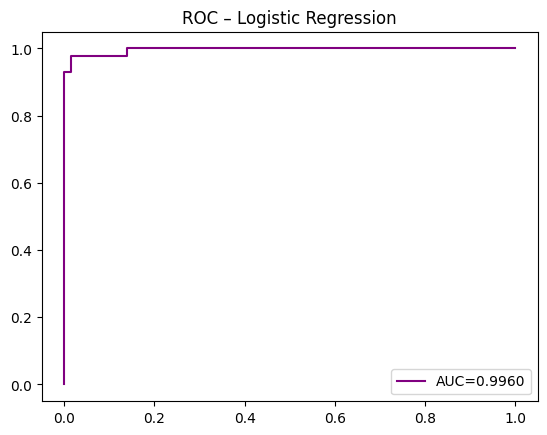

In [ ]:
y_prob_lr = lr.predict_proba(X_test_sc)[:,1]
fpr2, tpr2, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr2, tpr2, color="purple", label=f"AUC={auc(fpr2,tpr2):.4f}")
plt.title("ROC – Logistic Regression");
plt.legend();
plt.show()

Figure 3 – Elbow Method and Cluster Plot (K-Means, Mall Customers)

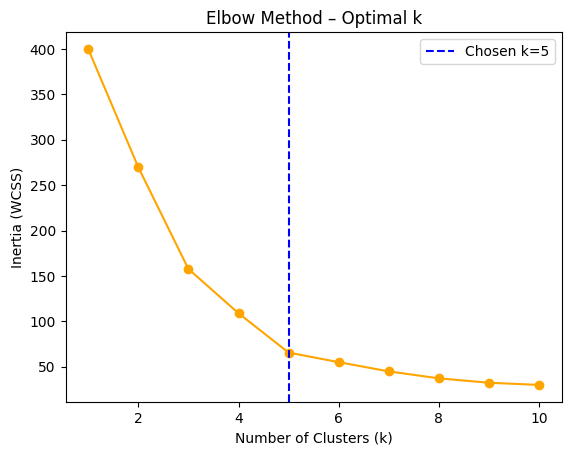

In [ ]:
# Elbow plot
plt.plot(range(1,11), inertias, "o-", color="orange")
plt.axvline(5, linestyle="--", color="blue", label="Chosen k=5")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method – Optimal k")
plt.legend()
plt.show()

Figure 4: K-Means Cluster Plot

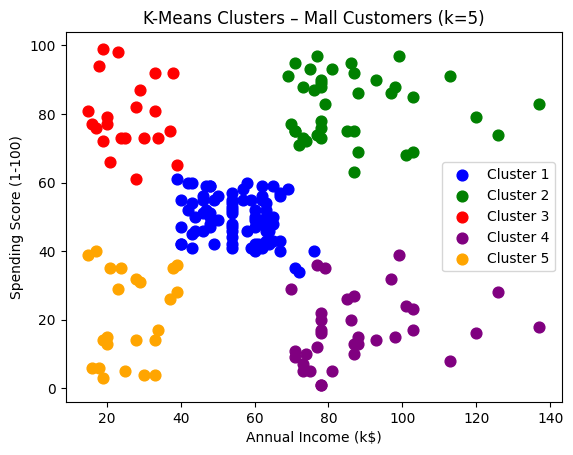

In [ ]:
# Cluster scatter plot
colors = ["blue","green","red","purple","orange"]
for i in range(5):
    mask = labels == i
    plt.scatter(df["Annual Income (k$)"][mask],
                df["Spending Score (1-100)"][mask],
                color=colors[i], label=f"Cluster {i+1}", s=60)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Clusters – Mall Customers (k=5)")
plt.legend()
plt.show()

Hierarchical Clustering Dendrogram and Segments

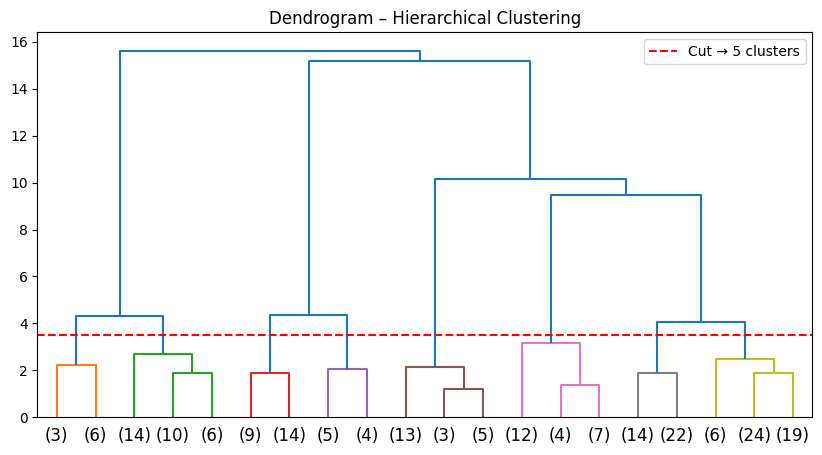

Linkage matrix computed | 5 clusters extracted


In [ ]:
# Step: Hierarchical Clustering

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

# Build linkage matrix using the SAME scaled data
Z = linkage(X_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=20, color_threshold=3.5)

# Draw cut line for 5 clusters
plt.axhline(y=3.5, color="red", linestyle="--", label="Cut → 5 clusters")
plt.legend()
plt.title("Dendrogram – Hierarchical Clustering");
plt.show()

# Extract 5 clusters
hc_labels = fcluster(Z, t=5, criterion="maxclust") - 1

# Output message
print("Linkage matrix computed | 5 clusters extracted")

loading data and training all models

In [ ]:
# Setup - To generate the figure
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import (train_test_split, GridSearchCV,
    RandomizedSearchCV, KFold, cross_val_score)
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, mean_squared_error, r2_score, mean_absolute_error, silhouette_score)
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.stats import uniform
from matplotlib.patches import Patch

COLS = ['#1565C0','#2E7D32','#E65100','#6A1B9A','#F57F17']

# Classification dataset
df_cls = pd.read_csv('Grid search.csv')
df_cls = df_cls.drop(columns=["id","Unnamed: 32"], errors="ignore")
df_cls["diagnosis"] = LabelEncoder().fit_transform(df_cls["diagnosis"])
X_cls = df_cls.drop("diagnosis", axis=1);  y_cls = df_cls["diagnosis"]
sc_cls = StandardScaler();  X_cls_sc = sc_cls.fit_transform(X_cls)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls_sc, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# Regression dataset
df_reg = pd.read_csv('Random search.csv')
for c in df_reg.select_dtypes(include="object").columns:
    df_reg[c] = LabelEncoder().fit_transform(df_reg[c].astype(str))
df_reg = df_reg.fillna(df_reg.median(numeric_only=True))
X_reg = df_reg.drop(["Id","SalePrice"], axis=1);  y_reg = df_reg["SalePrice"]
sc_reg = StandardScaler();  X_reg_sc = sc_reg.fit_transform(X_reg)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg_sc, y_reg, test_size=0.2, random_state=42)

# Unsupervised dataset
df_uns = pd.read_csv("unsupervised.csv")
X_uns = df_uns[["Annual Income (k$)","Spending Score (1-100)"]].values
sc_uns = StandardScaler();  X_uns_sc = sc_uns.fit_transform(X_uns)

# Train Random Forest (unscaled — tree based)
X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr_rf, y_tr_rf);  yp_rf = rf.predict(X_te_rf)
rf_acc  = accuracy_score(y_te_rf, yp_rf)
rf_prec = precision_score(y_te_rf, yp_rf)
rf_rec  = recall_score(y_te_rf, yp_rf)
rf_f1   = f1_score(y_te_rf, yp_rf)

# Train Logistic Regression (scaled)
lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_tr, y_tr);  yp_lr = lr.predict(X_te)
lr_acc  = accuracy_score(y_te, yp_lr)
lr_prec = precision_score(y_te, yp_lr)
lr_rec  = recall_score(y_te, yp_lr)
lr_f1   = f1_score(y_te, yp_lr)

# K-Means
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
km_labels = km5.fit_predict(X_uns_sc)
sil_km = silhouette_score(X_uns_sc, km_labels)

# Hierarchical Clustering
Z = linkage(X_uns_sc, method="ward")
hc_labels = fcluster(Z, t=5, criterion="maxclust") - 1
sil_hc = silhouette_score(X_uns_sc, hc_labels)

# Decision Tree baseline (classification)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_tr, y_tr);  yp_dt = dt.predict(X_te)
dt_acc  = accuracy_score(y_te, yp_dt)
dt_prec = precision_score(y_te, yp_dt)
dt_rec  = recall_score(y_te, yp_dt)
dt_f1   = f1_score(y_te, yp_dt)

# SVM Grid Search
param_grid = {"C": [0.1, 1], "kernel": ["linear", "rbf"]}
gs = GridSearchCV(SVC(probability=True, random_state=42), param_grid,
                  cv=5, scoring="f1", n_jobs=-1, return_train_score=True)
gs.fit(X_tr, y_tr)
yp_svm  = gs.best_estimator_.predict(X_te)
svm_acc  = accuracy_score(y_te, yp_svm)
svm_prec = precision_score(y_te, yp_svm)
svm_rec  = recall_score(y_te, yp_svm)
svm_f1   = f1_score(y_te, yp_svm)
gs_res   = pd.DataFrame(gs.cv_results_)
f1_means = list(gs_res["mean_test_score"])
f1_stds  = list(gs_res["std_test_score"])
best_idx = f1_means.index(max(f1_means))

# Decision Tree baseline (regression)
dtr = DecisionTreeRegressor(random_state=42)
dtr.fit(X_tr_r, y_tr_r);  yp_dtr = dtr.predict(X_te_r)
dtr_rmse = np.sqrt(mean_squared_error(y_te_r, yp_dtr))
dtr_mae  = mean_absolute_error(y_te_r, yp_dtr)
dtr_r2   = r2_score(y_te_r, yp_dtr)

# SVR Random Search
param_dist = {"C": uniform(0.1,100), "epsilon": uniform(0.01,1),
              "kernel": ["linear","rbf"]}
rs = RandomizedSearchCV(SVR(), param_dist, n_iter=20, cv=5,
                        scoring="neg_mean_squared_error",
                        n_jobs=-1, random_state=42)
rs.fit(X_tr_r, y_tr_r)
yp_svr   = rs.best_estimator_.predict(X_te_r)
svr_rmse = np.sqrt(mean_squared_error(y_te_r, yp_svr))
svr_mae  = mean_absolute_error(y_te_r, yp_svr)
svr_r2   = r2_score(y_te_r, yp_svr)
rs_res   = pd.DataFrame(rs.cv_results_)
rs_res["cv_rmse"] = np.sqrt(-rs_res["mean_test_score"])

# K-Fold CV (SVM + SVR with best params)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
bp = gs.best_params_;  rp = rs.best_params_
cv_acc  = cross_val_score(SVC(C=bp["C"],kernel=bp["kernel"],probability=True,random_state=42), X_cls_sc, y_cls, cv=kf, scoring="accuracy")
cv_f1   = cross_val_score(SVC(C=bp["C"],kernel=bp["kernel"],probability=True,random_state=42), X_cls_sc, y_cls, cv=kf, scoring="f1")
cv_r2   = cross_val_score(SVR(C=rp["C"],epsilon=rp["epsilon"],kernel=rp["kernel"]), X_reg_sc, y_reg, cv=kf, scoring="r2")
cv_rmse = np.sqrt(-cross_val_score(SVR(C=rp["C"],epsilon=rp["epsilon"],kernel=rp["kernel"]), X_reg_sc, y_reg, cv=kf, scoring="neg_mean_squared_error"))

print("All models trained and ready.")
print(f"RF:  Acc={rf_acc:.4f}  F1={rf_f1:.4f}")
print(f"LR:  Acc={lr_acc:.4f}  F1={lr_f1:.4f}")
print(f"KM:  Silhouette={sil_km:.4f}")
print(f"HC:  Silhouette={sil_hc:.4f}")
print(f"SVM: Acc={svm_acc:.4f}  F1={svm_f1:.4f}  Best:{gs.best_params_}")
print(f"SVR: RMSE=${svr_rmse:,.0f}  R2={svr_r2:.4f}  Best:{rs.best_params_}")
print(f"CV SVM: Acc={cv_acc.mean():.4f}  F1={cv_f1.mean():.4f}")
print(f"CV SVR: R2={cv_r2.mean():.4f}  RMSE=${cv_rmse.mean():,.0f}")

All models trained and ready.
RF:  Acc=0.9737  F1=0.9630
LR:  Acc=0.9649  F1=0.9512
KM:  Silhouette=0.5547
HC:  Silhouette=0.5538
SVM: Acc=0.9737  F1=0.9630  Best:{'C': 1, 'kernel': 'rbf'}
SVR: RMSE=$34,781  R2=0.8423  Best:{'C': np.float64(98.42308858067881), 'epsilon': np.float64(0.47676289324797994), 'kernel': 'linear'}
CV SVM: Acc=0.9789  F1=0.9715
CV SVR: R2=0.8108  RMSE=$33,473


Hierarchical Clustering Segments

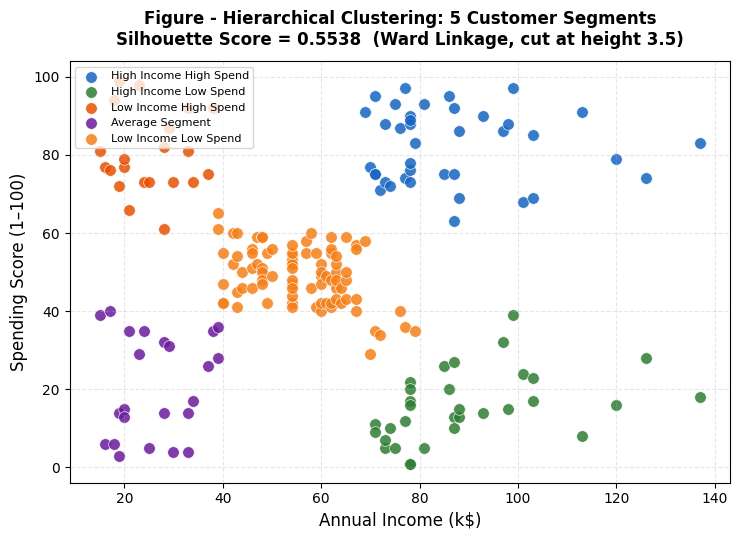

In [ ]:
# Hierarchical Clustering Segments
seg_names = ["High Income High Spend", "High Income Low Spend",
             "Low Income High Spend",  "Average Segment",
             "Low Income Low Spend"]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for i in range(5):
    mask = hc_labels == i
    ax.scatter(df_uns["Annual Income (k$)"][mask],
               df_uns["Spending Score (1-100)"][mask],
               s=70, color=COLS[i], alpha=0.85,
               label=seg_names[i], edgecolors="white", linewidths=0.5)

ax.set_xlabel("Annual Income (k$)", fontsize=12)
ax.set_ylabel("Spending Score (1–100)", fontsize=12)
ax.set_title(f"Figure - Hierarchical Clustering: 5 Customer Segments\n"
             f"Silhouette Score = {sil_hc:.4f}  (Ward Linkage, cut at height 3.5)",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

K-Means vs Hierarchical side by side

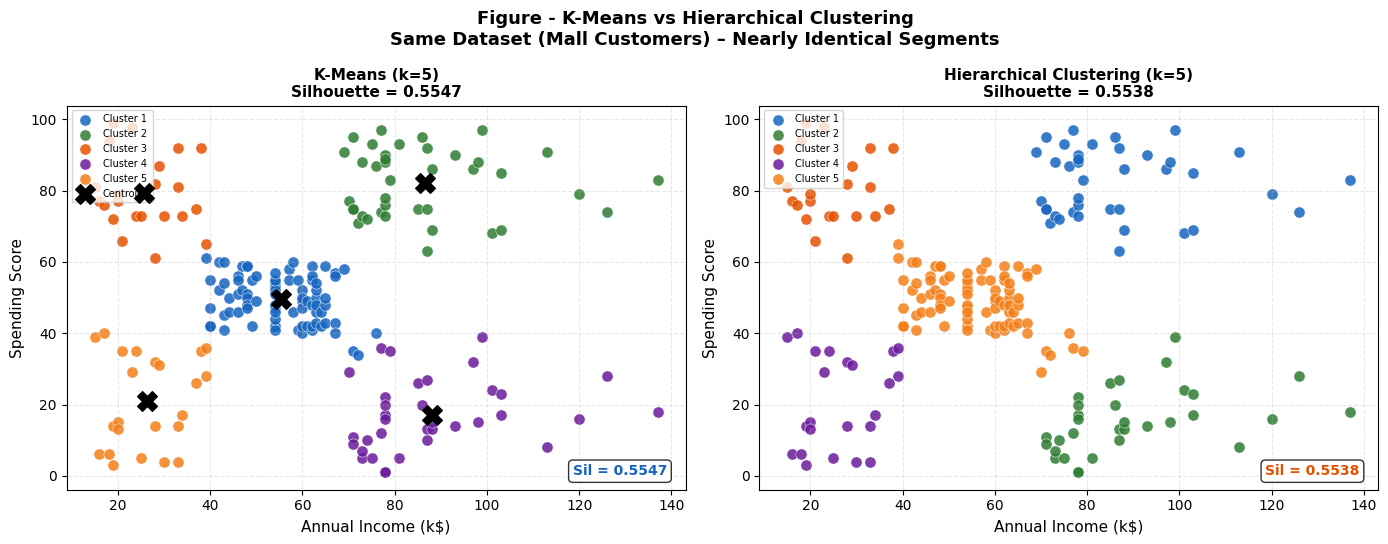

In [ ]:
# K-Means vs Hierarchical Clustering
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Figure - K-Means vs Hierarchical Clustering\n"
             "Same Dataset (Mall Customers) – Nearly Identical Segments",
             fontsize=13, fontweight="bold")

# Left: K-Means
for i in range(5):
    axes[0].scatter(df_uns["Annual Income (k$)"][km_labels==i],
                    df_uns["Spending Score (1-100)"][km_labels==i],
                    s=65, color=COLS[i], alpha=0.85,
                    label=f"Cluster {i+1}", edgecolors="white", linewidths=0.4)
ctrs = sc_uns.inverse_transform(km5.cluster_centers_)
axes[0].scatter(ctrs[:,0], ctrs[:,1], s=200, marker="X",
                c="black", zorder=6, label="Centroids")
axes[0].set_xlabel("Annual Income (k$)", fontsize=11)
axes[0].set_ylabel("Spending Score", fontsize=11)
axes[0].set_title(f"K-Means (k=5)\nSilhouette = {sil_km:.4f}",
                  fontsize=11, fontweight="bold")
axes[0].legend(fontsize=7, loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].text(0.97, 0.03, f"Sil = {sil_km:.4f}", transform=axes[0].transAxes,
             ha="right", va="bottom", fontsize=10, fontweight="bold",
             color="#1565C0", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Right: Hierarchical
for i in range(5):
    axes[1].scatter(df_uns["Annual Income (k$)"][hc_labels==i],
                    df_uns["Spending Score (1-100)"][hc_labels==i],
                    s=65, color=COLS[i], alpha=0.85,
                    label=f"Cluster {i+1}", edgecolors="white", linewidths=0.4)
axes[1].set_xlabel("Annual Income (k$)", fontsize=11)
axes[1].set_ylabel("Spending Score", fontsize=11)
axes[1].set_title(f"Hierarchical Clustering (k=5)\nSilhouette = {sil_hc:.4f}",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=7, loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.3)
axes[1].text(0.97, 0.03, f"Sil = {sil_hc:.4f}", transform=axes[1].transAxes,
             ha="right", va="bottom", fontsize=10, fontweight="bold",
             color="#E65100", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

A.6  Performance Metrics

Supervised Algorithms – Performance Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Random Forest metrics
print(f"RF  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"RF  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"RF  Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"RF  F1-Score : {f1_score(y_test, y_pred):.4f}")

# Logistic Regression metrics
print(f"LR  Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"LR  Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"LR  Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"LR  F1-Score : {f1_score(y_test, y_pred_lr):.4f}")

RF  Accuracy : 0.9737
RF  Precision: 1.0000
RF  Recall   : 0.9286
RF  F1-Score : 0.9630
LR  Accuracy : 0.9649
LR  Precision: 0.9750
LR  Recall   : 0.9286
LR  F1-Score : 0.9512


Unsupervised Metrics - Performance Metrics

In [ ]:
from sklearn.metrics import silhouette_score

sil_km = silhouette_score(X_uns_sc, km_labels)
sil_hc = silhouette_score(X_uns_sc, hc_labels)
print(f"K-Means  Silhouette: {sil_km:.4f} | Inertia: {km5.inertia_:.2f}")
print(f"HC       Silhouette: {sil_hc:.4f}")

K-Means  Silhouette: 0.5547 | Inertia: 65.57
HC       Silhouette: 0.5538


Random Forest vs Logistic Regression

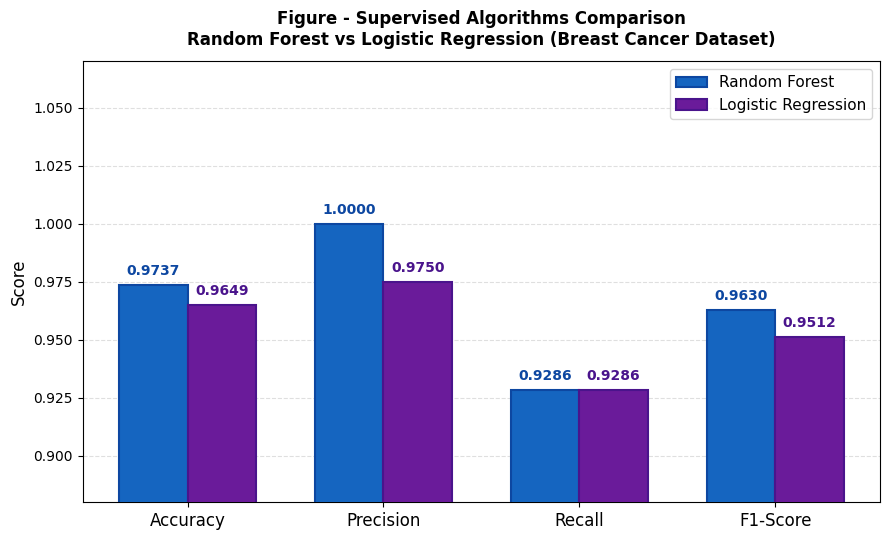

In [ ]:
# Random Forest vs Logistic Regression
mets   = ["Accuracy","Precision","Recall","F1-Score"]
rf_v   = [rf_acc, rf_prec, rf_rec, rf_f1]
lr_v   = [lr_acc, lr_prec, lr_rec, lr_f1]

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(4);  w = 0.35
b1 = ax.bar(x-w/2, rf_v, w, label="Random Forest",
            color="#1565C0", edgecolor="#0D47A1", linewidth=1.5, zorder=3)
b2 = ax.bar(x+w/2, lr_v, w, label="Logistic Regression",
            color="#6A1B9A", edgecolor="#4A148C", linewidth=1.5, zorder=3)

for b,v in zip(b1, rf_v):
    ax.text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.4f}",
            ha="center", va="bottom", fontsize=10, color="#0D47A1", fontweight="bold")
for b,v in zip(b2, lr_v):
    ax.text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.4f}",
            ha="center", va="bottom", fontsize=10, color="#4A148C", fontweight="bold")

ax.set_xticks(x);  ax.set_xticklabels(mets, fontsize=12)
ax.set_ylim(0.88, 1.07);  ax.set_ylabel("Score", fontsize=12)
ax.set_title("Figure - Supervised Algorithms Comparison\n"
             "Random Forest vs Logistic Regression (Breast Cancer Dataset)",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

B.1  Grid Search – Classification Model

Before Grid Search – Baseline Model (Decision Tree, No Tuning)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# BEFORE: plain Decision Tree with default settings (no tuning)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_before = dt.predict(X_test)

print("--- BEFORE (Decision Tree, no tuning) ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_before):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_before):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_before):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_before):.4f}")

--- BEFORE (Decision Tree, no tuning) ---
Accuracy  : 0.9298
Precision : 0.9048
Recall    : 0.9048
F1-Score  : 0.9048


Applying Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define 2 hyperparameters x 2 values = 4 total combinations
param_grid = {
    "n_estimators": [50, 100],      # number of trees
    "max_depth":    [None, 10]      # None = fully grown trees
}

# GridSearchCV: test ALL 4 combinations with 5-fold cross-validation
gs = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,          # 5 folds
    scoring    = "f1",       # optimise F1-Score
    n_jobs     = -1,         # use all CPU cores
    return_train_score = True
)
gs.fit(X_train, y_train)

print("Best Parameters Found:", gs.best_params_)
print("Best CV F1-Score     :", round(gs.best_score_, 4))

# Evaluate best model on test set
y_pred_after = gs.best_estimator_.predict(X_test)
print("--- AFTER (RF + Grid Search) ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_after):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_after):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_after):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_after):.4f}")

Best Parameters Found: {'max_depth': None, 'n_estimators': 50}
Best CV F1-Score     : 0.9561
--- AFTER (RF + Grid Search) ---
Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9286
F1-Score  : 0.9630


Hyperparameter Combinations Table

Load and Grid Search

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from matplotlib.patches import Patch

# Loading data
df = pd.read_csv("Grid search.csv")
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")
df["diagnosis"] = LabelEncoder().fit_transform(df["diagnosis"])
X = df.drop("diagnosis", axis=1);  y = df["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# BEFORE — plain Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train);  yp_b = dt.predict(X_test)
b_acc=accuracy_score(y_test,yp_b);  b_prec=precision_score(y_test,yp_b)
b_rec=recall_score(y_test,yp_b);    b_f1=f1_score(y_test,yp_b)

# AFTER — Grid Search
param_grid = {"n_estimators": [50, 100], "max_depth": [None, 10]}
gs = GridSearchCV(RandomForestClassifier(random_state=42), param_grid,
                  cv=5, scoring="f1", n_jobs=-1, return_train_score=True)
gs.fit(X_train, y_train)
yp_a = gs.best_estimator_.predict(X_test)
a_acc=accuracy_score(y_test,yp_a);  a_prec=precision_score(y_test,yp_a)
a_rec=recall_score(y_test,yp_a);    a_f1=f1_score(y_test,yp_a)

res         = pd.DataFrame(gs.cv_results_)
f1_means    = list(res["mean_test_score"])
f1_stds     = list(res["std_test_score"])
best_idx    = f1_means.index(max(f1_means))
combo_labels= []
for p in res["params"]:
    d = "None\n(full depth)" if p["max_depth"] is None else str(p["max_depth"])
    combo_labels.append(f"n_estimators={p['n_estimators']}\nmax_depth={d}")

print("Best params:", gs.best_params_)
print(f"BEFORE: Acc={b_acc:.4f}  F1={b_f1:.4f}")
print(f"AFTER:  Acc={a_acc:.4f}  F1={a_f1:.4f}")

Best params: {'max_depth': None, 'n_estimators': 50}
BEFORE: Acc=0.9298  F1=0.9048
AFTER:  Acc=0.9737  F1=0.9630


All 4 Grid Search combinations tested with their mean CV F1-Score and standard deviation.

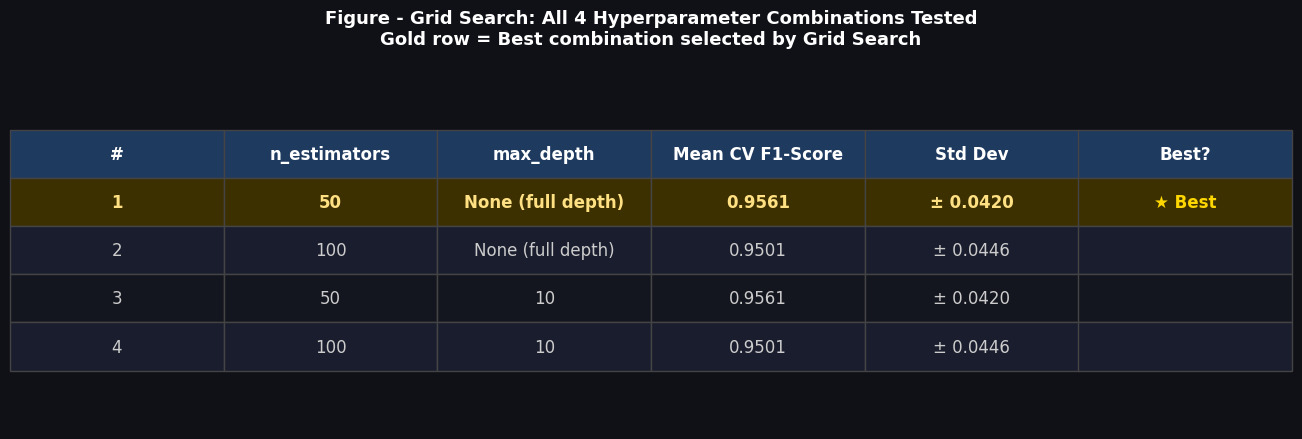

In [ ]:
fig, ax7 = plt.subplots(figsize=(13, 4.5))
fig.patch.set_facecolor("#0f1117");  ax7.set_facecolor("#0f1117");  ax7.axis("off")

col_labels = ["#", "n_estimators", "max_depth", "Mean CV F1-Score", "Std Dev", "Best?"]
table_data = []
for i, p in enumerate(res["params"]):
    d = "None (full depth)" if p["max_depth"] is None else str(p["max_depth"])
    is_best = "★ Best" if p == gs.best_params_ else ""
    table_data.append([str(i+1), str(p["n_estimators"]), d,
                       f"{f1_means[i]:.4f}", f"± {f1_stds[i]:.4f}", is_best])

tbl = ax7.table(cellText=table_data, colLabels=col_labels, loc="center", cellLoc="center")
tbl.auto_set_font_size(False);  tbl.set_fontsize(12);  tbl.scale(1.2, 2.8)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#444")
    if r == 0:
        cell.set_facecolor("#1e3a5f");  cell.set_text_props(color="white", fontweight="bold")
    elif table_data[r-1][5] == "★ Best":
        cell.set_facecolor("#3d3000")
        cell.set_text_props(color="#FFD700" if c == 5 else "#ffe082", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#1a1d2e");  cell.set_text_props(color="#cccccc")
    else:
        cell.set_facecolor("#14161f");  cell.set_text_props(color="#cccccc")

ax7.set_title("Figure - Grid Search: All 4 Hyperparameter Combinations Tested\n"
              "Gold row = Best combination selected by Grid Search",
              color="white", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout();  plt.show()



Bar chart comparing all 4 combinations – the best combination is highlighted in blue.

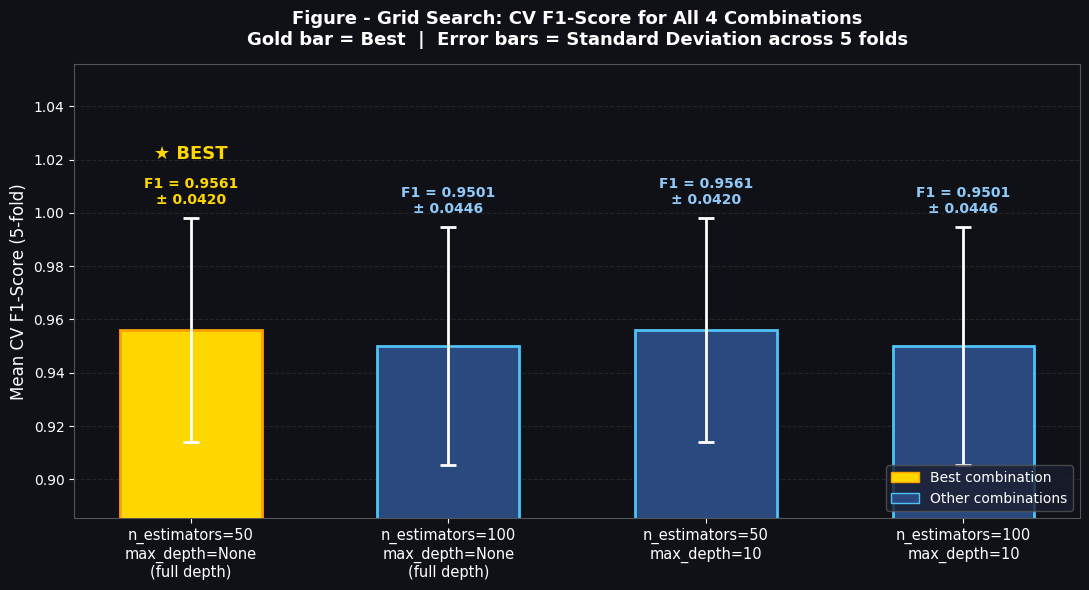

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#0f1117");  ax.set_facecolor("#0f1117")

bar_colors  = ["#FFD700" if i == best_idx else "#2a4a7f" for i in range(4)]
edge_colors = ["#FFA000" if i == best_idx else "#4fc3f7"  for i in range(4)]
bars = ax.bar(range(4), f1_means, color=bar_colors, edgecolor=edge_colors,
               linewidth=2, width=0.55, zorder=3)

ax.errorbar(range(4), f1_means, yerr=f1_stds,
             fmt="none", color="white", capsize=6, capthick=2, elinewidth=2, zorder=4)

for i, (bar, mean, std) in enumerate(zip(bars, f1_means, f1_stds)):
    color = "#FFD700" if i == best_idx else "#90caf9"
    ax.text(bar.get_x()+bar.get_width()/2, mean+std+0.004,
             f"F1 = {mean:.4f}\n± {std:.4f}",
             ha="center", va="bottom", color=color, fontsize=10, fontweight="bold")

ax.text(best_idx, f1_means[best_idx]+f1_stds[best_idx]+0.022,
         "★ BEST", ha="center", color="#FFD700", fontsize=13, fontweight="bold")

ax.set_xticks(range(4));  ax.set_xticklabels(combo_labels, color="white", fontsize=10.5)
ax.tick_params(colors="white")
ax.set_ylim(min(f1_means)-max(f1_stds)-0.02, max(f1_means)+max(f1_stds)+0.055)
ax.set_ylabel("Mean CV F1-Score (5-fold)", color="white", fontsize=12)
ax.yaxis.set_tick_params(labelcolor="white")
ax.grid(axis="y", color="#2a2a2a", linewidth=0.8, linestyle="--", alpha=0.8, zorder=0)
for sp in ax.spines.values(): sp.set_edgecolor("#555")
ax.set_title("Figure - Grid Search: CV F1-Score for All 4 Combinations\n"
              "Gold bar = Best  |  Error bars = Standard Deviation across 5 folds",
              color="white", fontsize=13, fontweight="bold", pad=14)
legend_els = [Patch(facecolor="#FFD700", edgecolor="#FFA000", label="Best combination"),
              Patch(facecolor="#2a4a7f", edgecolor="#4fc3f7", label="Other combinations")]
ax.legend(handles=legend_els, facecolor="#1a1d2e", edgecolor="#555",
           labelcolor="white", fontsize=10, loc="lower right")
plt.tight_layout();  plt.show()


Before (Decision Tree, red) vs After (RF + Grid Search, blue) – improvement shown for all metrics.

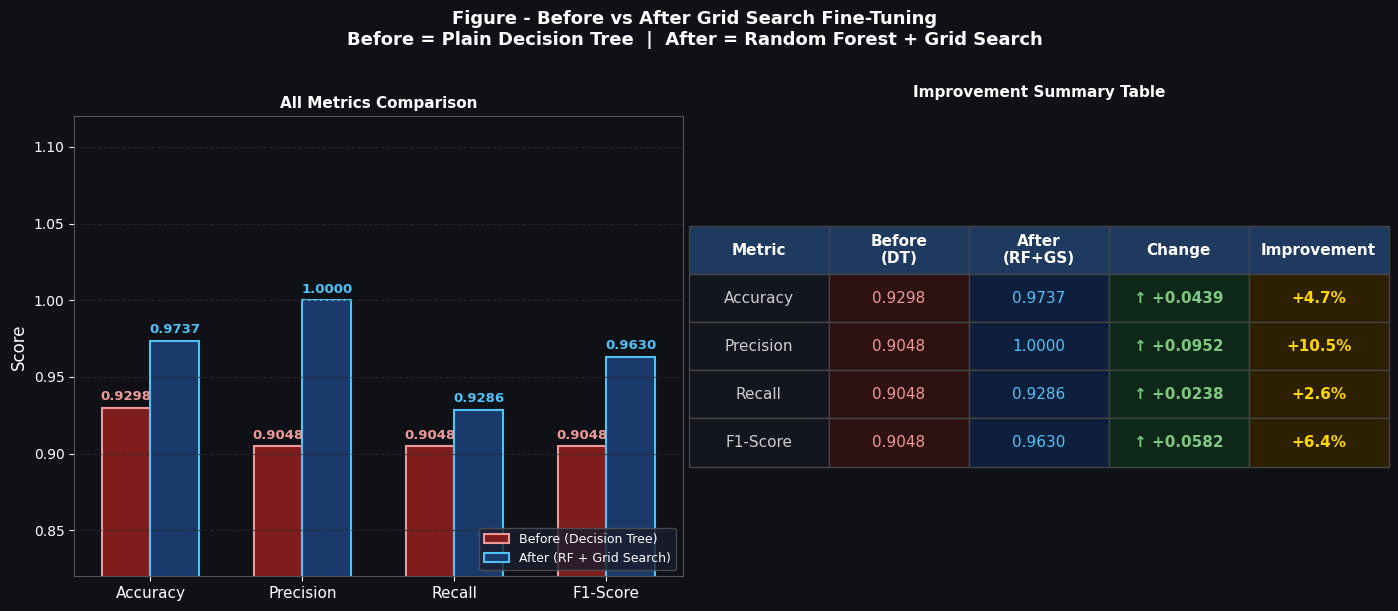

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Figure - Before vs After Grid Search Fine-Tuning\n"
              "Before = Plain Decision Tree  |  After = Random Forest + Grid Search",
              color="white", fontsize=13, fontweight="bold", y=1.01)

metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
before_vals  = [b_acc, b_prec, b_rec, b_f1]
after_vals   = [a_acc, a_prec, a_rec, a_f1]

# Left: grouped bar chart
ax = axes[0];  ax.set_facecolor("#0f1117")
x = np.arange(4);  w = 0.32
b1 = ax.bar(x-w/2, before_vals, w, label="Before (Decision Tree)",
            color="#7f1d1d", edgecolor="#ef9a9a", linewidth=1.5)
b2 = ax.bar(x+w/2, after_vals,  w, label="After (RF + Grid Search)",
            color="#1a3a6b", edgecolor="#4fc3f7", linewidth=1.5)
for bar, val in zip(b1, before_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f"{val:.4f}",
            ha="center", color="#ef9a9a", fontsize=9.5, fontweight="bold")
for bar, val in zip(b2, after_vals):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f"{val:.4f}",
            ha="center", color="#4fc3f7", fontsize=9.5, fontweight="bold")

ax.set_xticks(x);  ax.set_xticklabels(metric_names, color="white", fontsize=11)
ax.tick_params(colors="white");  ax.set_ylim(0.82, 1.12)
ax.set_ylabel("Score", color="white", fontsize=12)
ax.set_title("All Metrics Comparison", color="white", fontsize=11, fontweight="bold")
ax.grid(axis="y", color="#2a2a2a", linewidth=0.8, linestyle="--", alpha=0.8)
for sp in ax.spines.values(): sp.set_edgecolor("#555")
ax.legend(facecolor="#1a1d2e", edgecolor="#555", labelcolor="white", fontsize=9, loc="lower right")

# Right: improvement summary table
ax2 = axes[1];  ax2.set_facecolor("#0f1117");  ax2.axis("off")
summary_data = []
for name, bv, av in zip(metric_names, before_vals, after_vals):
    diff = av - bv;  pct = diff / bv * 100
    summary_data.append([name, f"{bv:.4f}", f"{av:.4f}", f"↑ +{diff:.4f}", f"+{pct:.1f}%"])

tbl2 = ax2.table(cellText=summary_data,
    colLabels=["Metric","Before\n(DT)","After\n(RF+GS)","Change","Improvement"],
    loc="center", cellLoc="center")
tbl2.auto_set_font_size(False);  tbl2.set_fontsize(11);  tbl2.scale(1.15, 2.9)
for (r, c), cell in tbl2.get_celld().items():
    cell.set_edgecolor("#444")
    if r == 0:
        cell.set_facecolor("#1e3a5f");  cell.set_text_props(color="white", fontweight="bold")
    elif c == 1:
        cell.set_facecolor("#2d1010");  cell.set_text_props(color="#ef9a9a")
    elif c == 2:
        cell.set_facecolor("#0d1f3c");  cell.set_text_props(color="#4fc3f7")
    elif c == 3:
        cell.set_facecolor("#0d2818");  cell.set_text_props(color="#81c784", fontweight="bold")
    elif c == 4:
        cell.set_facecolor("#2d2000");  cell.set_text_props(color="#FFD700", fontweight="bold")
    else:
        cell.set_facecolor("#14161f");  cell.set_text_props(color="#cccccc")
ax2.set_title("Improvement Summary Table", color="white", fontsize=11, fontweight="bold", pad=14)

plt.tight_layout();
plt.show()


B.2  Random Search – Regression Model

Before Random Search – Baseline (Decision Tree, No Tuning)

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Loading and preprocessing regression dataset
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df_reg = pd.read_csv("Random search.csv")
for col in df_reg.select_dtypes(include="object").columns:
    df_reg[col] = LabelEncoder().fit_transform(df_reg[col].astype(str))
df_reg = df_reg.fillna(df_reg.median(numeric_only=True))
X_reg = df_reg.drop(["Id", "SalePrice"], axis=1)
y_reg = df_reg["SalePrice"]

from sklearn.model_selection import train_test_split
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# BEFORE: plain Decision Tree Regressor (no tuning)
dtr = DecisionTreeRegressor(random_state=42)
dtr.fit(X_tr_r, y_tr_r)
y_pred_before_r = dtr.predict(X_te_r)

print("--- BEFORE (Decision Tree Regressor, no tuning) ---")
print(f"RMSE : ${np.sqrt(mean_squared_error(y_te_r, y_pred_before_r)):,.0f}")
print(f"MAE  : ${mean_absolute_error(y_te_r, y_pred_before_r):,.0f}")
print(f"R2   : {r2_score(y_te_r, y_pred_before_r):.4f}")

--- BEFORE (Decision Tree Regressor, no tuning) ---
RMSE : $42,097
MAE  : $27,759
R2   : 0.7690


Applying Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

# Defining wide ranges for each hyperparameter
param_dist = {
    "n_estimators": randint(50, 300),  # sample from 50 to 299
    "max_depth"   : randint(3, 20)     # sample from 3 to 19
}

# RandomizedSearchCV: test 20 random combinations
rs = RandomizedSearchCV(
    estimator   = RandomForestRegressor(random_state=42),
    param_distributions = param_dist,
    n_iter      = 20,          # test 20 random combos
    cv          = 5,           # 5-fold cross-validation
    scoring     = "neg_mean_squared_error",
    n_jobs      = -1,
    random_state = 42
)
rs.fit(X_tr_r, y_tr_r)

print("Best Parameters Found:", rs.best_params_)
y_pred_after_r = rs.best_estimator_.predict(X_te_r)
print("AFTER (RF + Random Search)")
print(f"RMSE : ${np.sqrt(mean_squared_error(y_te_r, y_pred_after_r)):,.0f}")
print(f"MAE  : ${mean_absolute_error(y_te_r, y_pred_after_r):,.0f}")
print(f"R2   : {r2_score(y_te_r, y_pred_after_r):.4f}")

Best Parameters Found: {'max_depth': 12, 'n_estimators': 269}
AFTER (RF + Random Search)
RMSE : $28,865
MAE  : $17,637
R2   : 0.8914


Sampled Combinations and Results

All 20 randomly sampled combinations – star marks the best, colour shows CV RMSE (green = better).

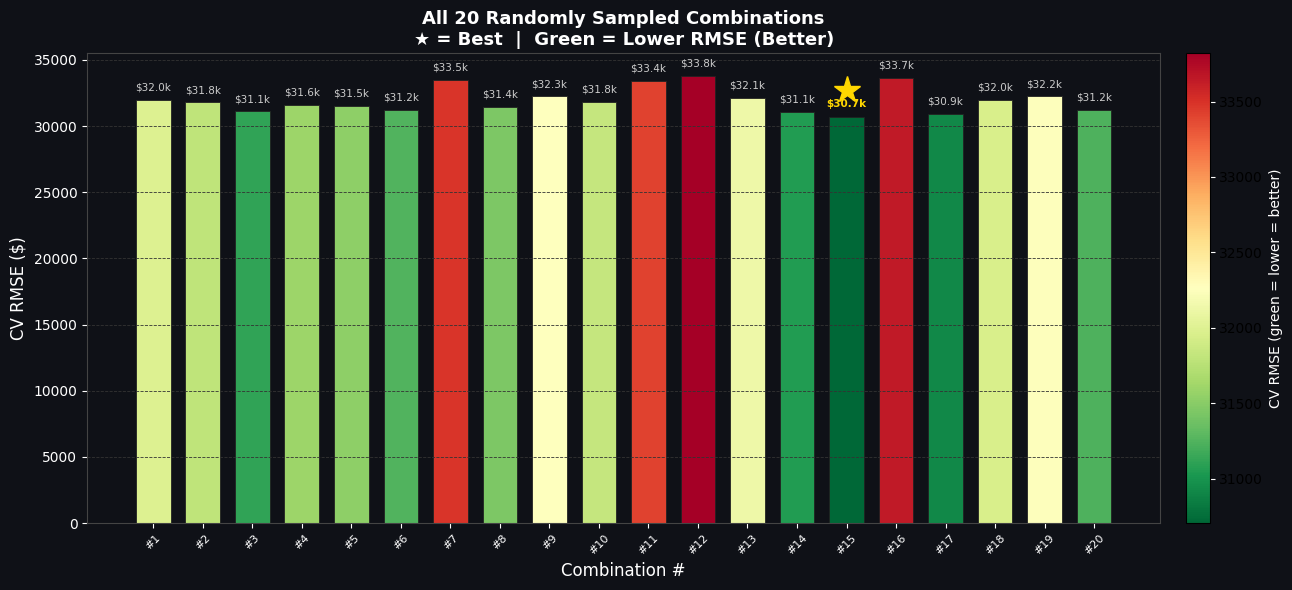

In [ ]:
import matplotlib.cm as cm
from scipy.stats import randint
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Random Search (20 combinations)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

param_dist = {
    "n_estimators":      randint(50, 300),
    "max_depth":         [None, 5, 10, 15, 20],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf":  randint(1, 10),
}
rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=42), param_dist,
    n_iter=20, cv=5, scoring="neg_mean_squared_error",
    random_state=42, return_train_score=True
)
rs.fit(X_train_r, y_train_r)

rmse_vals = np.sqrt(-rs.cv_results_["mean_test_score"])
best_idx  = np.argmin(rmse_vals)
best_rf_r = rs.best_estimator_
y_pred_rf = best_rf_r.predict(X_test_r)

dt_r = DecisionTreeRegressor(random_state=42)
dt_r.fit(X_train_r, y_train_r)
y_pred_dt = dt_r.predict(X_test_r)

def reg_metrics(yt, yp):
    return (np.sqrt(mean_squared_error(yt, yp)),
            mean_absolute_error(yt, yp),
            r2_score(yt, yp))

dt_rmse, dt_mae, dt_r2 = reg_metrics(y_test_r, y_pred_dt)
rf_rmse, rf_mae, rf_r2 = reg_metrics(y_test_r, y_pred_rf)

# All 20 combinations coloured by RMSE
fig10, ax10 = plt.subplots(figsize=(14, 6))
fig10.patch.set_facecolor("#0f1117"); ax10.set_facecolor("#0f1117")

norm   = plt.Normalize(vmin=rmse_vals.min(), vmax=rmse_vals.max())
colors = cm.RdYlGn(1 - norm(rmse_vals))   # low RMSE = green
x_pos  = np.arange(20)

bars = ax10.bar(x_pos, rmse_vals, color=colors, edgecolor="#222", linewidth=0.6, width=0.7)

ax10.plot(best_idx, rmse_vals[best_idx] + 2000, marker="*",
          markersize=20, color="#FFD700", zorder=5, linestyle="None")


for i, (bar, v) in enumerate(zip(bars, rmse_vals)):
    clr = "#FFD700" if i == best_idx else "#cccccc"
    ax10.text(bar.get_x() + bar.get_width()/2, v + 700,
              f"${v/1000:.1f}k", ha="center", fontsize=7.5,
              color=clr, fontweight="bold" if i == best_idx else "normal")

ax10.set_xlabel("Combination #", color="white", fontsize=12)
ax10.set_ylabel("CV RMSE ($)", color="white", fontsize=12)
ax10.set_title("All 20 Randomly Sampled Combinations\n★ = Best  |  Green = Lower RMSE (Better)",
               color="white", fontsize=13, fontweight="bold", pad=6)
ax10.set_xticks(x_pos)
ax10.set_xticklabels([f"#{i+1}" for i in x_pos], color="#aaa", fontsize=8, rotation=45)
ax10.tick_params(colors="white")
for sp in ax10.spines.values(): sp.set_edgecolor("#444")
ax10.grid(axis="y", color="#333", linewidth=0.6, linestyle="--")

sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax10, pad=0.02)
cbar.set_label("CV RMSE (green = lower = better)", color="white", fontsize=10)
cbar.ax.yaxis.set_tick_params(color="white")

plt.tight_layout()
plt.savefig("RandomSearch_Combos.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()


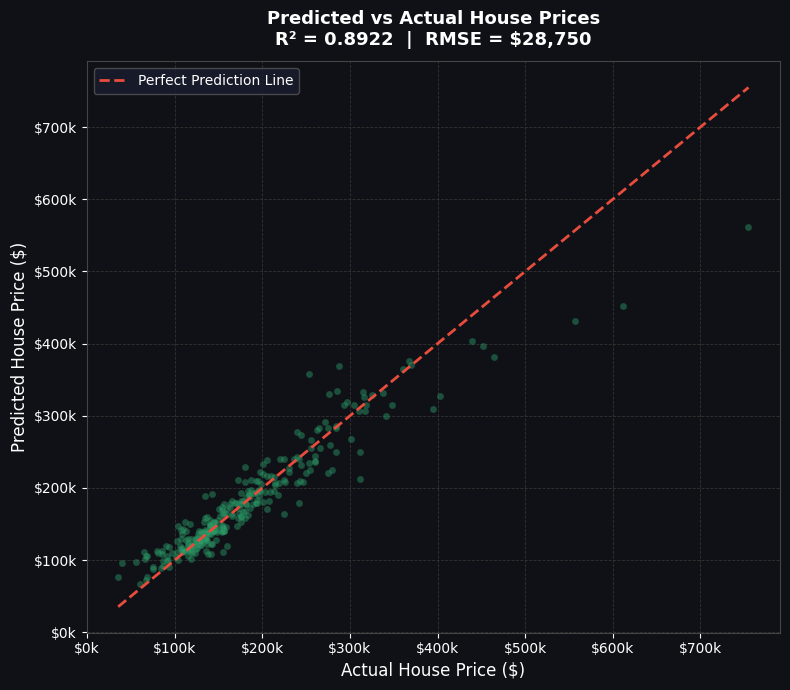

In [ ]:
# Predicted vs Actual
fig11, ax11 = plt.subplots(figsize=(8, 7))
fig11.patch.set_facecolor("#0f1117"); ax11.set_facecolor("#0f1117")

mn = min(y_test_r.min(), y_pred_rf.min())
mx = max(y_test_r.max(), y_pred_rf.max())

ax11.scatter(y_test_r, y_pred_rf, alpha=0.45, s=22,
             color="#2e9e6b", edgecolors="#1a6b47", linewidth=0.3, zorder=3)
ax11.plot([mn, mx], [mn, mx], color="#e74c3c", linewidth=2,
          linestyle="--", label="Perfect Prediction Line", zorder=4)

ax11.set_xlabel("Actual House Price ($)", color="white", fontsize=12)
ax11.set_ylabel("Predicted House Price ($)", color="white", fontsize=12)
ax11.set_title(f"Predicted vs Actual House Prices\n"
               f"R² = {rf_r2:.4f}  |  RMSE = ${rf_rmse:,.0f}",
               color="white", fontsize=13, fontweight="bold", pad=12)
ax11.tick_params(colors="white")
for sp in ax11.spines.values(): sp.set_edgecolor("#444")
ax11.grid(color="#333", linewidth=0.6, linestyle="--")
ax11.legend(facecolor="#1a1d2e", edgecolor="#555", labelcolor="white", fontsize=10)
ax11.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax11.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))

plt.tight_layout()
plt.savefig("Predicted_vs_Actual.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

/tmp/ipykernel_3521/993840531.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, color="white", fontsize=9)
/tmp/ipykernel_3521/993840531.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, color="white", fontsize=9)
/tmp/ipykernel_3521/993840531.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, color="white", fontsize=9)


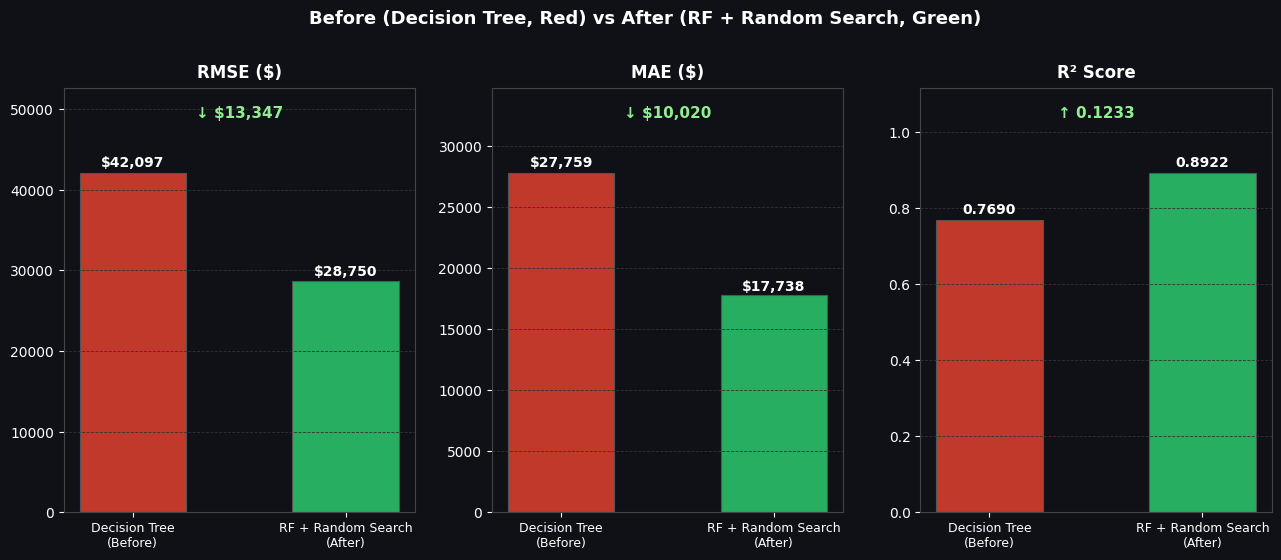


Best Params : {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 103}
DT  → RMSE: $42,097  MAE: $27,759  R²: 0.7690
RF  → RMSE: $28,750  MAE: $17,738  R²: 0.8922


In [ ]:
# FIGURE : Before vs After – 3 regression metrics
fig12, axes = plt.subplots(1, 3, figsize=(13, 5.5))
fig12.patch.set_facecolor("#0f1117")
fig12.suptitle("Before (Decision Tree, Red) vs After (RF + Random Search, Green)",
               color="white", fontsize=13, fontweight="bold", y=1.01)

metric_data = [
    ("RMSE ($)",  [dt_rmse, rf_rmse], False),
    ("MAE ($)",   [dt_mae,  rf_mae],  False),
    ("R² Score",  [dt_r2,   rf_r2],   True),
]
xlabels = ["Decision Tree\n(Before)", "RF + Random Search\n(After)"]

for ax, (title, vals, higher_better) in zip(axes, metric_data):
    ax.set_facecolor("#0f1117")
    b = ax.bar(xlabels, vals, color=["#c0392b", "#27ae60"],
               edgecolor="#555", linewidth=0.8, width=0.5)

    for bar, v in zip(b, vals):
        fmt = f"${v:,.0f}" if "$" in title else f"{v:.4f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                fmt, ha="center", va="bottom", color="white",
                fontsize=10, fontweight="bold")

    diff     = vals[1] - vals[0]
    improved = (diff < 0 and not higher_better) or (diff > 0 and higher_better)
    arrow    = "↓" if not higher_better else "↑"
    clr      = "#90ee90" if improved else "#ff6666"
    fmt_d    = f"${abs(diff):,.0f}" if "$" in title else f"{abs(diff):.4f}"
    ax.annotate(f"{arrow} {fmt_d}", xy=(0.5, 0.93), xycoords="axes fraction",
                ha="center", fontsize=11, color=clr, fontweight="bold")

    ax.set_title(title, color="white", fontsize=12, fontweight="bold", pad=8)
    ax.tick_params(colors="white")
    ax.set_xticklabels(xlabels, color="white", fontsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor("#444")
    ax.grid(axis="y", color="#333", linewidth=0.6, linestyle="--")
    ax.set_ylim(0, max(vals) * 1.25)

plt.tight_layout()
plt.savefig("Before_vs_After_Regression.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

print(f"\nBest Params : {rs.best_params_}")
print(f"DT  → RMSE: ${dt_rmse:,.0f}  MAE: ${dt_mae:,.0f}  R²: {dt_r2:.4f}")
print(f"RF  → RMSE: ${rf_rmse:,.0f}  MAE: ${rf_mae:,.0f}  R²: {rf_r2:.4f}")

B.3  K-Fold Cross-Validation – Both Models

Code Implementation with Annotations

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import numpy as np
import pandas as pd # Import pandas to use concat

# Create 5-fold splitter with shuffling
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# shuffle=True randomises order before splitting to avoid bias

# Classification: Breast Cancer
rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)

# Reconstructing the full X and y for classification from their train/test splits
X_classification = pd.concat([X_train, X_test])
y_classification = pd.concat([y_train, y_test])

cv_acc = cross_val_score(rf_cls, X_classification, y_classification, cv=kf, scoring="accuracy")
cv_f1  = cross_val_score(rf_cls, X_classification, y_classification, cv=kf, scoring="f1")

print("Classification – Accuracy per fold:", cv_acc.round(4))
print(f"Mean Accuracy : {cv_acc.mean():.4f}  Std: {cv_acc.std():.4f}")
print("Classification – F1 per fold     :", cv_f1.round(4))
print(f"Mean F1-Score : {cv_f1.mean():.4f}  Std: {cv_f1.std():.4f}")

# Regression: House Prices
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

cv_rmse = np.sqrt(-cross_val_score(rf_reg, X_reg, y_reg,
           cv=kf, scoring="neg_mean_squared_error"))
cv_r2   = cross_val_score(rf_reg, X_reg, y_reg, cv=kf, scoring="r2")

print("Regression - RMSE per fold:", cv_rmse.round(0))
print(f"Mean RMSE : ${cv_rmse.mean():,.0f}  Std: ${cv_rmse.std():,.0f}")
print("Regression - R2 per fold  :", cv_r2.round(4))
print(f"Mean R2   : {cv_r2.mean():.4f}  Std: {cv_r2.std():.4f}")

Classification – Accuracy per fold: [0.9561 0.9649 0.9825 0.9386 0.9646]
Mean Accuracy : 0.9613  Std: 0.0142
Classification – F1 per fold     : [0.9412 0.95   0.9744 0.9263 0.9487]
Mean F1-Score : 0.9481  Std: 0.0156
Regression - RMSE per fold: [29184. 26023. 45826. 28243. 23582.]
Mean RMSE : $30,572  Std: $7,869
Regression - R2 per fold  : [0.889  0.9004 0.6199 0.873  0.8936]
Mean R2   : 0.8352  Std: 0.1080


Cross-Validation Results Table

Full 5-fold CV results table. Green row = average across all 5 folds with standard deviation.

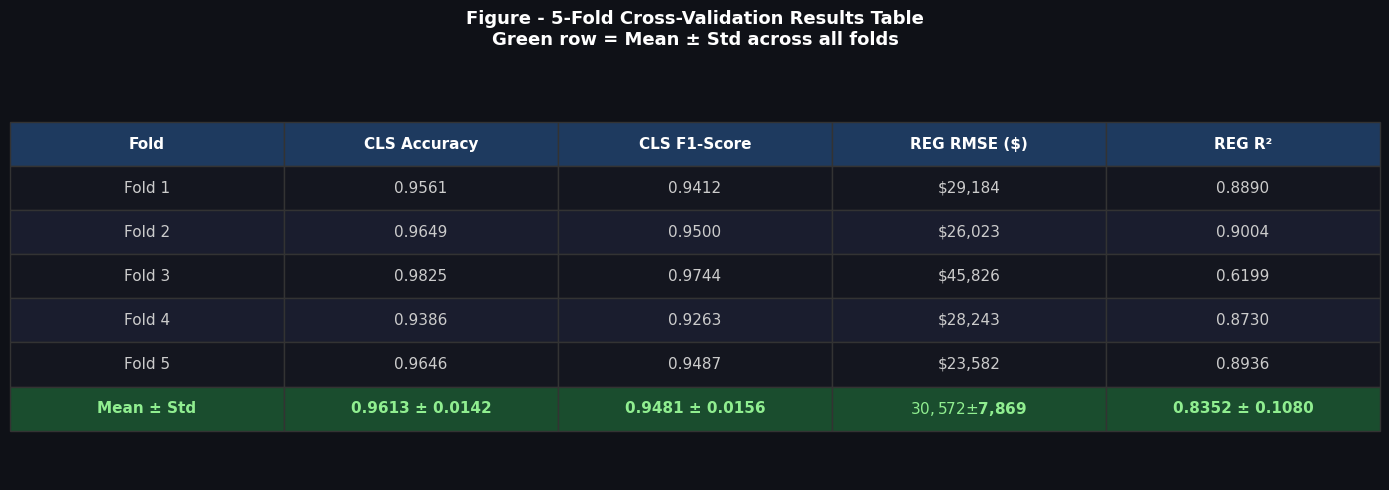

In [ ]:
import matplotlib.pyplot as plt
# Re-run CV scores (or use your existing cv_acc, cv_f1 variables)
cls_acc  = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42),
                           X_classification, y_classification, cv=kf, scoring="accuracy")
cls_f1   = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42),
                           X_classification, y_classification, cv=kf, scoring="f1")
reg_rmse = np.sqrt(-cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42),
                                    X_reg, y_reg, cv=kf, scoring="neg_mean_squared_error"))
reg_r2   = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42),
                           X_reg, y_reg, cv=kf, scoring="r2")

# FIGURE : Full 5-Fold CV Results Table
fig13, ax13 = plt.subplots(figsize=(14, 5))
fig13.patch.set_facecolor("#0f1117"); ax13.set_facecolor("#0f1117"); ax13.axis("off")

col_labels = ["Fold", "CLS Accuracy", "CLS F1-Score", "REG RMSE ($)", "REG R²"]
table_data = []
for i in range(5):
    table_data.append([
        f"Fold {i+1}",
        f"{cls_acc[i]:.4f}",
        f"{cls_f1[i]:.4f}",
        f"${reg_rmse[i]:,.0f}",
        f"{reg_r2[i]:.4f}",
    ])
# Green summary row at bottom
table_data.append([
    "Mean ± Std",
    f"{cls_acc.mean():.4f} ± {cls_acc.std():.4f}",
    f"{cls_f1.mean():.4f} ± {cls_f1.std():.4f}",
    f"${reg_rmse.mean():,.0f} ± ${reg_rmse.std():,.0f}",
    f"{reg_r2.mean():.4f} ± {reg_r2.std():.4f}",
])
tbl = ax13.table(cellText=table_data, colLabels=col_labels,
                 loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2.5)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#333")
    if r == 0:                         # header row
        cell.set_facecolor("#1e3a5f")
        cell.set_text_props(color="white", fontweight="bold")
    elif r == len(table_data):         # mean row (green)
        cell.set_facecolor("#1a4d2e")
        cell.set_text_props(color="#90ee90", fontweight="bold")
    elif r % 2 == 0:                   # alternating shading
        cell.set_facecolor("#1a1d2e")
        cell.set_text_props(color="#cccccc")
    else:
        cell.set_facecolor("#14161f")
        cell.set_text_props(color="#cccccc")

ax13.set_title("Figure - 5-Fold Cross-Validation Results Table\n"
               "Green row = Mean ± Std across all folds",
               color="white", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("Figure_CV_Table.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

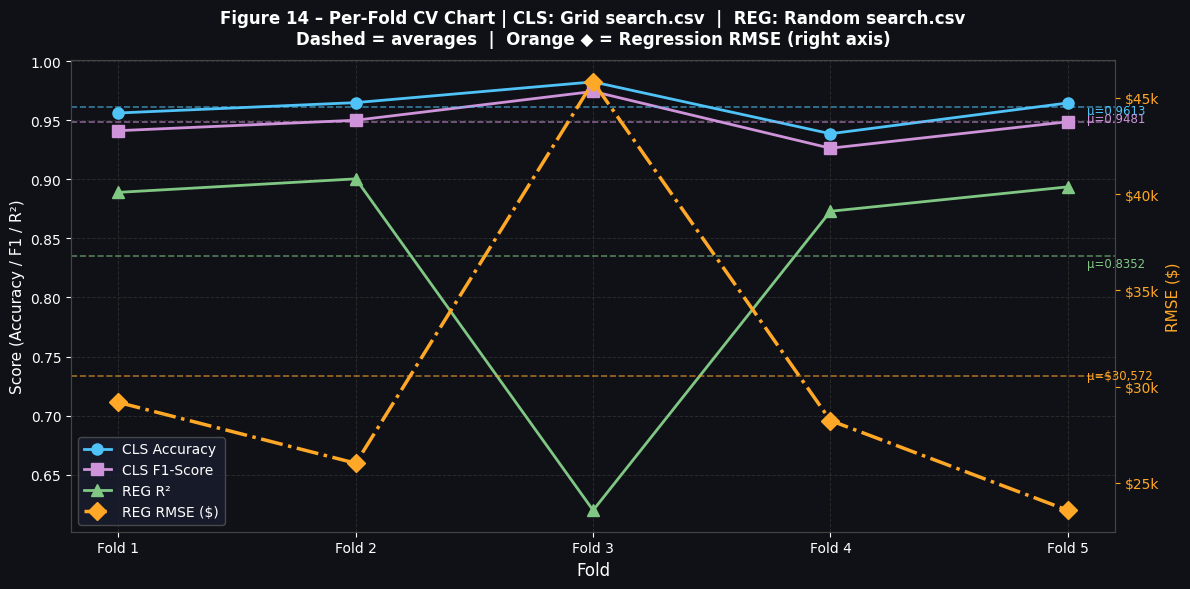

In [ ]:
# FIGURE : Per-Fold Chart with dual y-axis

fig14, ax_l = plt.subplots(figsize=(12, 6))
fig14.patch.set_facecolor("#0f1117"); ax_l.set_facecolor("#0f1117")
ax_r = ax_l.twinx()

x = np.arange(1, 6)
l1, = ax_l.plot(x, cls_acc,  color="#4fc3f7", marker="o", markersize=8, linewidth=2, label="CLS Accuracy")
l2, = ax_l.plot(x, cls_f1,   color="#ce93d8", marker="s", markersize=8, linewidth=2, label="CLS F1-Score")
l3, = ax_l.plot(x, reg_r2,   color="#81c784", marker="^", markersize=8, linewidth=2, label="REG R²")

ax_l.axhline(cls_acc.mean(), color="#4fc3f7", linewidth=1.2, linestyle="--", alpha=0.6)
ax_l.axhline(cls_f1.mean(),  color="#ce93d8", linewidth=1.2, linestyle="--", alpha=0.6)
ax_l.axhline(reg_r2.mean(),  color="#81c784", linewidth=1.2, linestyle="--", alpha=0.6)

for arr, color, offset in [(cls_acc, "#4fc3f7", -0.003),
                            (cls_f1,  "#ce93d8",  0.003),
                            (reg_r2,  "#81c784", -0.006)]:
    ax_l.text(5.08, arr.mean()+offset, f"μ={arr.mean():.4f}",
              color=color, fontsize=8.5, va="center")

l4, = ax_r.plot(x, reg_rmse, color="#FFA726", marker="D", markersize=9,
                linewidth=2.5, linestyle="-.", label="REG RMSE ($)")
ax_r.axhline(reg_rmse.mean(), color="#FFA726", linewidth=1.2, linestyle="--", alpha=0.6)
ax_r.text(5.08, reg_rmse.mean(), f"μ=${reg_rmse.mean():,.0f}",
          color="#FFA726", fontsize=8.5, va="center")

ax_l.set_xlabel("Fold", color="white", fontsize=12)
ax_l.set_ylabel("Score (Accuracy / F1 / R²)", color="white", fontsize=11)
ax_r.set_ylabel("RMSE ($)", color="#FFA726", fontsize=11)
ax_l.set_xticks(x); ax_l.set_xticklabels([f"Fold {i}" for i in x], color="white")
ax_l.tick_params(colors="white"); ax_r.tick_params(colors="#FFA726")
ax_r.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
for sp in ax_l.spines.values(): sp.set_edgecolor("#444")
for sp in ax_r.spines.values(): sp.set_edgecolor("#444")
ax_l.grid(color="#2a2a2a", linewidth=0.7, linestyle="--")
ax_l.set_title("Figure 14 – Per-Fold CV Chart | CLS: Grid search.csv  |  REG: Random search.csv\nDashed = averages  |  Orange ◆ = Regression RMSE (right axis)",
               color="white", fontsize=12, fontweight="bold", pad=12)

lines = [l1, l2, l3, l4]
ax_l.legend(lines, [l.get_label() for l in lines],
            facecolor="#1a1d2e", edgecolor="#555", labelcolor="white",
            fontsize=10, loc="lower left")
plt.tight_layout()
plt.savefig("Figure14.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()